# Neo-M3GAN (Experimental): Standalone Generation

This notebook is a **completely standalone** tool for generating synthetic clinical data using the advanced **Neo-M3GAN** architecture (Self-Attention + Bilateral Coupling).

## Setup Instructions

1.  **Files Required**: You only need to upload your trained Neo checkpoint (e.g., `neo_m3gan_100.pth`) and the metadata `clinical_scaler.pkl` (optional).
2.  **Run**: Execute the cells in order to generate synthetic patient data.

### 1. Neo-M3GAN Architecture and Utilities
The code below contains the advanced Neo-M3GAN architecture, including Temporal Self-Attention.

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- UTILITIES ---
def np_rounding(data, decimals=0):
    return np.around(data, decimals)

def renormlizer(data, max_min, min_val):
    return data * max_min + min_val

# --- NEO-NETWORKS ---
class TemporalSelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(TemporalSelfAttention, self).__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim // 8)
        self.key = nn.Linear(hidden_dim, hidden_dim // 8)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, time_steps, hidden_dim = x.size()
        proj_query = self.query(x).view(batch_size, -1, time_steps).permute(0, 2, 1) # B x T x C
        proj_key = self.key(x).view(batch_size, -1, time_steps) # B x C x T
        energy = torch.bmm(proj_query, proj_key) # B x T x T
        attention = torch.softmax(energy, dim=-1)
        proj_value = self.value(x).view(batch_size, -1, time_steps) # B x C x T
        out = torch.bmm(proj_value, attention.permute(0, 2, 1)) # B x C x T
        out = out.view(batch_size, time_steps, hidden_dim)
        return self.gamma * out + x

class VAE_Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers=3):
        super(VAE_Encoder, self).__init__()
        dropout_rate = 0.2 if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_rate)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x_t, hidden_state):
        out, new_hidden = self.lstm(x_t, hidden_state)
        out_squeeze = out.squeeze(1)
        mu = self.fc_mu(out_squeeze)
        logvar = self.fc_logvar(out_squeeze)
        mu = torch.clamp(mu, min=-20.0, max=20.0)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z, mu, logvar, new_hidden

class VAE_Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, num_layers=3):
        super(VAE_Decoder, self).__init__()
        dropout_rate = 0.2 if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(latent_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_rate)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z_t, hidden_state):
        out, new_hidden = self.lstm(z_t, hidden_state)
        logits = self.fc_out(out.squeeze(1))
        reconstruction = torch.sigmoid(logits)
        return reconstruction, logits, new_hidden

class AutoregressiveVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, enc_layers, dec_layers, time_steps):
        super(AutoregressiveVAE, self).__init__()
        self.time_steps = time_steps
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.encoder = VAE_Encoder(input_dim * 2, hidden_dim, latent_dim, enc_layers)
        self.decoder = VAE_Decoder(latent_dim, hidden_dim, input_dim, dec_layers)

    def forward(self, x):
        batch_size = x.size(0)
        device = x.device
        enc_hidden = (torch.zeros(self.encoder.lstm.num_layers, batch_size, self.hidden_dim, device=device),
                      torch.zeros(self.encoder.lstm.num_layers, batch_size, self.hidden_dim, device=device))
        dec_hidden = (torch.zeros(self.decoder.lstm.num_layers, batch_size, self.hidden_dim, device=device),
                      torch.zeros(self.decoder.lstm.num_layers, batch_size, self.hidden_dim, device=device))
        c_prev = torch.zeros(batch_size, self.input_dim, device=device)
        rec_list, logits_list, mu_list, logvar_list, z_list = [], [], [], [], []
        for t in range(self.time_steps):
            x_t = x[:, t, :]
            x_hat = x_t - torch.sigmoid(c_prev)
            enc_in = torch.cat([x_t, x_hat], dim=1).unsqueeze(1)
            z_t, mu_t, logvar_t, enc_hidden = self.encoder(enc_in, enc_hidden)
            rec_t, logits_t, dec_hidden = self.decoder(z_t.unsqueeze(1), dec_hidden)
            c_prev = logits_t
            rec_list.append(rec_t.unsqueeze(1))
            logits_list.append(logits_t.unsqueeze(1))
            mu_list.append(mu_t.unsqueeze(1))
            logvar_list.append(logvar_t.unsqueeze(1))
            z_list.append(z_t.unsqueeze(1))
        return torch.cat(rec_list, 1), torch.cat(logits_list, 1), torch.cat(mu_list, 1), torch.cat(logvar_list, 1), torch.cat(z_list, 1)

    def reconstruct_decoder(self, z_seq):
        batch_size = z_seq.size(0)
        device = z_seq.device
        dec_hidden = (torch.zeros(self.decoder.lstm.num_layers, batch_size, self.hidden_dim, device=device),
                      torch.zeros(self.decoder.lstm.num_layers, batch_size, self.hidden_dim, device=device))
        rl, ll = [], []
        for t in range(self.time_steps):
            rt, lt, dec_hidden = self.decoder(z_seq[:, t, :].unsqueeze(1), dec_hidden)
            rl.append(rt.unsqueeze(1)); ll.append(lt.unsqueeze(1))
        return torch.cat(rl, 1), torch.cat(ll, 1)

class SequenceDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim, time_steps, num_layers=3):
        super(SequenceDiscriminator, self).__init__()
        dropout_rate = 0.2 if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_rate)
        self.attn = TemporalSelfAttention(hidden_dim)
        self.fc = spectral_norm(nn.Linear(hidden_dim * time_steps, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.attn(out)
        out_flat = torch.flatten(out, start_dim=1)
        logits = self.fc(out_flat).squeeze(-1)
        return logits, out

class BilateralLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(BilateralLSTMCell, self).__init__()
        self.hidden_dim = hidden_dim
        self.ln = nn.Linear(input_dim + 2 * hidden_dim, 4 * hidden_dim, bias=False)

    def forward(self, x, h_self, c_self, h_coupled):
        combined = torch.cat([x, h_self, h_coupled], dim=1)
        gates = self.ln(combined)
        i, f, o, ct = gates.chunk(4, dim=1)
        c_next = torch.sigmoid(f) * c_self + torch.sigmoid(i) * torch.tanh(ct)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

class BilateralGenerator(nn.Module):
    def __init__(self, noise_dim, hidden_dim, latent_dim, num_layers=3):
        super(BilateralGenerator, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.cl = nn.ModuleList([BilateralLSTMCell(noise_dim if i == 0 else hidden_dim, hidden_dim) for i in range(num_layers)])
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def forward(self, noise_seq, h_coupled_states):
        b, t, dev = noise_seq.size(0), noise_seq.size(1), noise_seq.device
        h = [torch.zeros(b, self.hidden_dim, device=dev) for _ in range(self.num_layers)]
        c = [torch.zeros(b, self.hidden_dim, device=dev) for _ in range(self.num_layers)]
        ol = []
        for t_step in range(t):
            xt = noise_seq[:, t_step, :]
            for i in range(self.num_layers):
                h[i], c[i] = self.cl[i](xt, h[i], c[i], h_coupled_states[i]); xt = h[i]
            ol.append(torch.sigmoid(self.fc_out(xt)).unsqueeze(1))
        return torch.cat(ol, 1), h

class JointGenerator(nn.Module):
    def __init__(self, c_noise_dim, d_noise_dim, hidden_dim, c_latent_dim, d_latent_dim, num_layers=3):
        super(JointGenerator, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.c_gen = BilateralGenerator(c_noise_dim, hidden_dim, c_latent_dim, num_layers)
        self.d_gen = BilateralGenerator(d_noise_dim, hidden_dim, d_latent_dim, num_layers)
        self.c_attn = TemporalSelfAttention(hidden_dim)
        self.d_attn = TemporalSelfAttention(hidden_dim)

    def forward(self, noise_c, noise_d):
        b, t, dev = noise_c.size(0), noise_c.size(1), noise_c.device
        ch, cc, dh, dc = [[torch.zeros(b, self.hidden_dim, device=dev) for _ in range(self.num_layers)] for _ in range(4)]
        cf, df = [], []
        for t_step in range(t):
            cx, dx = noise_c[:, t_step, :], noise_d[:, t_step, :]
            for i in range(self.num_layers):
                ch[i], cc[i] = self.c_gen.cl[i](cx, ch[i], cc[i], dh[i]); cx = ch[i]
            cf.append(cx.unsqueeze(1))
            for i in range(self.num_layers):
                dh[i], dc[i] = self.d_gen.cl[i](dx, dh[i], dc[i], ch[i]); dx = dh[i]
            df.append(dx.unsqueeze(1))
        return self.c_gen.fc_out(self.c_attn(torch.cat(cf, 1))), self.d_gen.fc_out(self.d_attn(torch.cat(df, 1)))

### 2. Configuration and Interactive Generation
Adjust the paths and run the cell to generate synthetic clinical data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


📂 Loading checkpoint: /content/drive/MyDrive/EHRMGAN/Models/neo_m3gan_200.pth...
✅ Detected dims: 104 continuous, 13 discrete, 512 hidden units.

Feature Selection:
Available Continuous Features: [0] alanine aminotransferase, [1] albumin, [2] albumin ascites, [3] albumin pleural, [4] albumin urine, [5] alkaline phosphate, [6] anion gap, [7] asparate aminotransferase, [8] basophils, [9] bicarbonate, [10] bilirubin, [11] blood urea nitrogen, [12] co2, [13] co2 (etco2, pco2, etc.), [14] calcium, [15] calcium ionized, [16] calcium urine, [17] cardiac index, [18] cardiac output thermodilution, [19] cardiac output fick, [20] central venous pressure, [21] chloride, [22] chloride urine, [23] cholesterol, [24] cholesterol hdl, [25] cholesterol ldl, [26] creatinine, [27] creatinine ascites, [28] creatinine body fluid, [29] creatinine pleural, [30] creatinine urine, [31] diastolic blood pressure, [32] eosinophils, [33] fibrinogen, [34] fraction inspired oxygen, [35] fraction inspired oxygen set, 

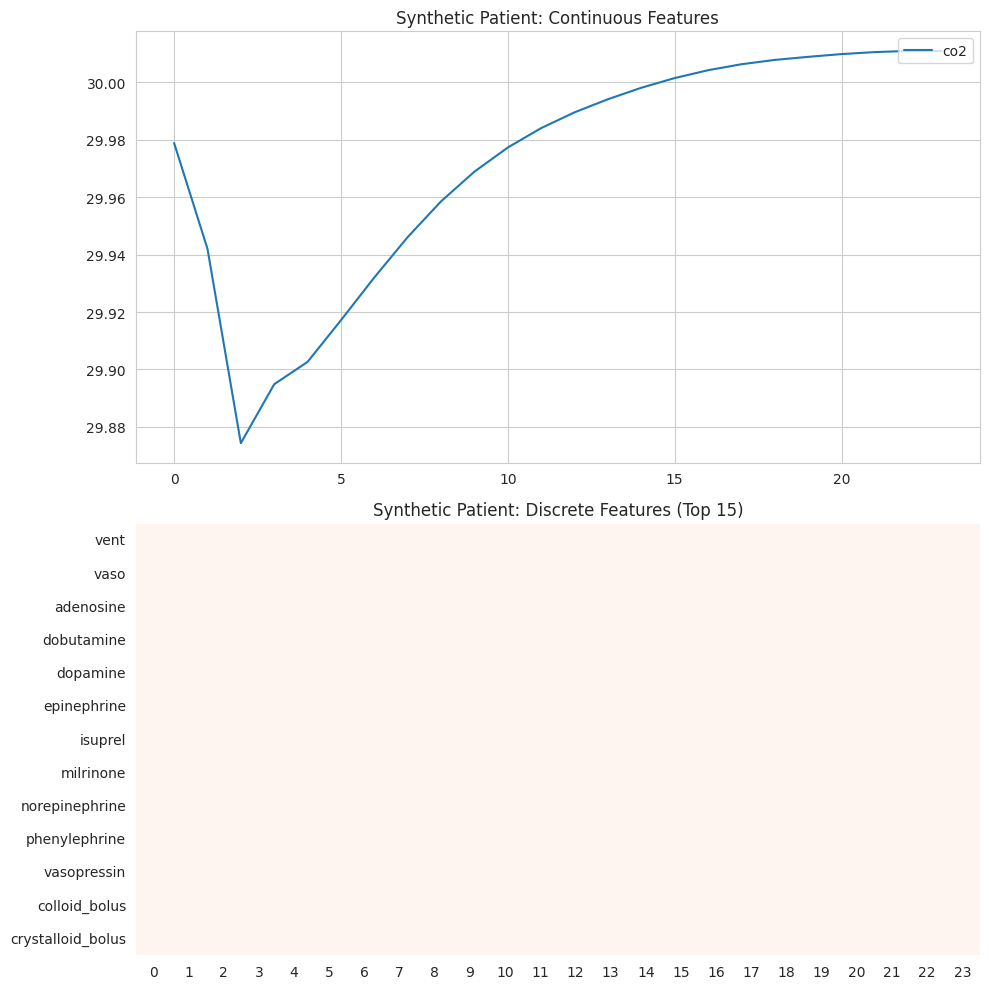

In [ ]:
class Args:
    checkpoint = "/content/drive/MyDrive/EHRMGAN/Models/neo_m3gan_200.pth"
    scaler_path = "/content/drive/MyDrive/EHRMGAN/data/mimic3/clinical_scaler.pkl"
    gen_num_units = 512
    gen_num_layers = 3
    enc_layers = 3
    dec_layers = 3
    time_steps = 24
    c_dim = 104
    d_dim = 13

args = Args()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def generate():
    if not os.path.exists(args.checkpoint):
        print(f"❌ Checkpoint not found at {args.checkpoint}. Please upload it.")
        return

    print(f"📂 Loading checkpoint: {args.checkpoint}...")
    ckpt = torch.load(args.checkpoint, map_location=device)

    # --- AUTO-DETECT DIMENSIONS ---
    try:
        c_dim = ckpt['c_vae']['decoder.fc_out.weight'].shape[0]
        d_dim = ckpt['d_vae']['decoder.fc_out.weight'].shape[0]
        hidden_dim = ckpt['c_vae']['decoder.fc_out.weight'].shape[1]
        print(f"✅ Detected dims: {c_dim} continuous, {d_dim} discrete, {hidden_dim} hidden units.")
    except Exception as e:
        print(f"⚠️ Could not auto-detect dims from checkpoint: {e}. Using defaults.")
        c_dim, d_dim, hidden_dim = args.c_dim, args.d_dim, args.gen_num_units

    c_vae = AutoregressiveVAE(c_dim, hidden_dim, 25, args.enc_layers, args.dec_layers, args.time_steps).to(device)
    d_vae = AutoregressiveVAE(d_dim, hidden_dim, 25, args.enc_layers, args.dec_layers, args.time_steps).to(device)
    noise_dim = min(int(c_dim / 2), int(d_dim / 2))
    joint_gen = JointGenerator(noise_dim, noise_dim, hidden_dim, 25, 25, args.gen_num_layers).to(device)

    c_vae.load_state_dict(ckpt['c_vae'])
    d_vae.load_state_dict(ckpt['d_vae'])
    joint_gen.c_gen.load_state_dict(ckpt['c_gen'])
    joint_gen.d_gen.load_state_dict(ckpt['d_gen'])
    c_vae.eval(); d_vae.eval(); joint_gen.eval()

    # Handle Scaler
    scaler = None
    if os.path.exists(args.scaler_path):
        with open(args.scaler_path, 'rb') as f: scaler = pickle.load(f)
        c_names, d_names = scaler['feature_names'], scaler['discrete_names']
    else:
        c_names, d_names = [f"C{i}" for i in range(c_dim)], [f"D{i}" for i in range(d_dim)]

    print("\nFeature Selection:")
    print(f"Available Continuous Features: {', '.join([f'[{i}] {name}' for i, name in enumerate(c_names)])}")
    selection = input("Enter feature indices to plot (e.g. 0,1,5), or 'all', or 'random': ").strip().lower()

    if selection == 'all':
        plot_indices = list(range(c_dim))
    elif selection == 'random':
        plot_indices = np.random.choice(c_dim, min(5, c_dim), replace=False).tolist()
    else:
        try:
            plot_indices = [int(i.strip()) for i in selection.split(',') if i.strip().isdigit()]
            if not plot_indices: plot_indices = [0]
        except:
            plot_indices = [0]

    while True:
        print(f"\n📂 Generating synthetic patient sequence...")
        with torch.no_grad():
            z_c, z_d = joint_gen(torch.randn(1, args.time_steps, noise_dim, device=device),
                                 torch.randn(1, args.time_steps, noise_dim, device=device))
            fake_c, _ = c_vae.reconstruct_decoder(z_c)
            fake_d, _ = d_vae.reconstruct_decoder(z_d)

        fake_c = fake_c.cpu().numpy()[0]
        fake_d = np_rounding(fake_d.cpu().numpy()[0])

        if scaler:
            fake_c = renormlizer(fake_c.reshape(1, args.time_steps, -1), scaler['maxes'] - scaler['mins'], scaler['mins'])[0]

        sns.set_style("whitegrid")
        fig, axes = plt.subplots(2, 1, figsize=(10, 10))

        # Plot 1: Continuous Features
        for i in plot_indices:
            if i < c_dim: axes[0].plot(fake_c[:, i], label=c_names[i])
        axes[0].set_title("Synthetic Patient: Continuous Features"); axes[0].legend(loc='upper right')

        # Plot 2: Discrete Features
        sns.heatmap(fake_d.T[:15, :], ax=axes[1], cmap="Reds", yticklabels=d_names[:15], cbar=False)
        axes[1].set_title("Synthetic Patient: Discrete Features (Top 15)")

        plt.tight_layout(); plt.show()

        cont = input("Generate another synthetic patient? (y/n): ")
        if cont.lower() != 'y': break

generate()
